# Run and review the Heston hedging study

This notebook walks through the completed procedure using its saved outputs. The numerical design was fixed before hedge outcomes. Values are simulated research data, not observations taken from another paper.

The parameter source is [Poulsen, Schenk-Hoppé and Ewald (2009), Table 2](https://d-nb.info/1191914100/34). Contract choices, perturbations, fees, schedules, and path counts are this project's design choices. See `PROTOCOL.md` for the full rationale and scope.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
if not (ROOT / 'simulation/protocol.json').exists():
    ROOT = ROOT.parent
P = json.loads((ROOT / 'simulation/protocol.json').read_text())
R = ROOT / 'simulation/results'
assert (R / 'complete.json').exists()
display(pd.DataFrame({'Market P': P['market'], 'Pricing Q': P['pricing']}))
display(pd.DataFrame([P['pilot'], P['main']], index=['pilot','main']))

,Market P,Pricing Q
mu,0.1000,NaN
kappa,4.7500,2.7500
theta,0.0483,0.0834
xi,0.5500,0.5500
rho,-0.5690,-0.5690


,n_paths,substeps,seed,maturity_days,strike_over_forward
pilot,128,8,20260924,63.0,1.0
main,4096,8,20260925,NaN,NaN


## 1. Inspect one path and its holdings

The pilot uses 128 paths and a 63-day forward-ATM call. Path 0 was selected before inspecting its outcome. The cash plot and ledger below use 10 bps to expose every cost entry; the initial diagnostic comparison uses zero fees.

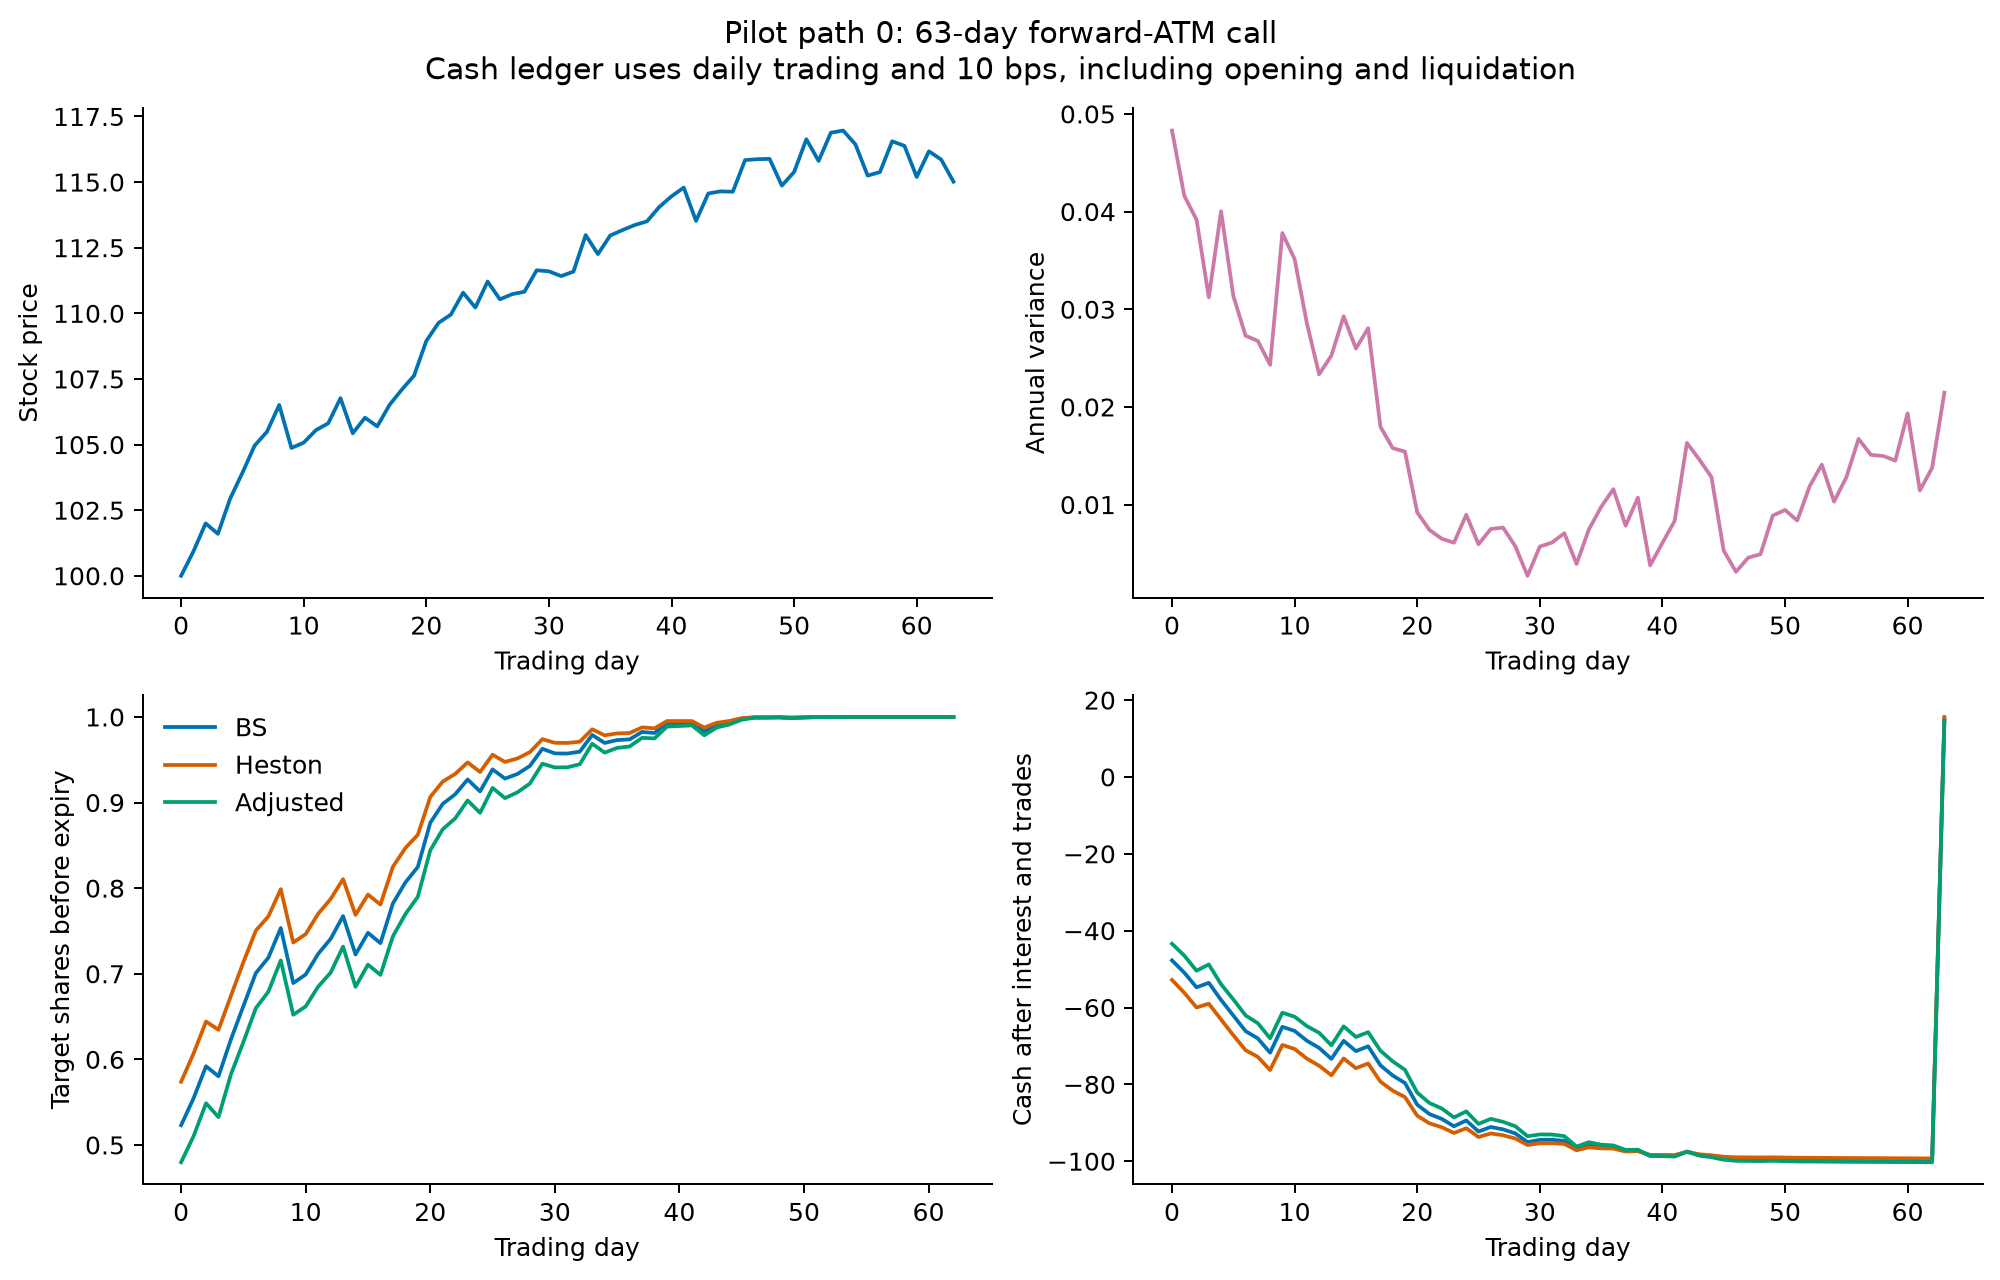

In [2]:
display(Image(filename=str(R/'pilot_path_ledger.png')))

## 2. Reconcile cash through settlement

`cash_before + interest - trade * spot - fee = cash_after`. At expiry, the stock holding is zero after liquidation. The terminal error is `cash_after - payoff`. Nominal cumulative fees are a diagnostic and are not subtracted again.

In [3]:
for strategy in ['BS','Heston','Adjusted']:
    ledger = pd.read_csv(R/f'ledger_{strategy}.csv')
    display(Markdown(f'**{strategy}: opening rows and final settlement**'))
    display(pd.concat([ledger.head(2),ledger.tail(2)]))

**BS: opening rows and final settlement**

,day,time_years,event,spot,target_holdings,cash_before,interest,trade,fees,cumulative_fees,holdings,cash_after,portfolio,payoff,terminal_error
0,0,0.000000,open,100.000000,0.523092,4.618403,0.000000,0.523092,0.052309,0.052309,0.523092,-47.743108,4.566094,NaN,NaN
1,1,0.003968,rebalance,100.927803,0.554603,-47.743108,-0.007579,0.031511,0.003180,0.055490,0.554603,-50.934216,5.040661,NaN,NaN
62,62,0.246032,rebalance,115.857128,1.000000,-99.782030,-0.015840,0.000000,0.000000,0.142753,1.000000,-99.797870,16.059258,NaN,NaN
63,63,0.250000,liquidate,115.015530,NaN,-99.797870,-0.015842,-1.000000,0.115016,0.257768,0.000000,15.086802,15.086802,14.010513,1.076289


**Heston: opening rows and final settlement**

,day,time_years,event,spot,target_holdings,cash_before,interest,trade,fees,cumulative_fees,holdings,cash_after,portfolio,payoff,terminal_error
0,0,0.000000,open,100.000000,0.573866,4.618403,0.000000,5.738659e-01,5.738659e-02,0.057387,0.573866,-52.825569,4.561017,NaN,NaN
1,1,0.003968,rebalance,100.927803,0.606844,-52.825569,-0.008386,3.297810e-02,3.328407e-03,0.060715,0.606844,-56.165690,5.081737,NaN,NaN
62,62,0.246032,rebalance,115.857128,1.000000,-99.262351,-0.015757,4.809042e-12,5.571618e-13,0.138176,1.000000,-99.278108,16.579020,NaN,NaN
63,63,0.250000,liquidate,115.015530,NaN,-99.278108,-0.015760,-1.000000e+00,1.150155e-01,0.253192,0.000000,15.606646,15.606646,14.010513,1.596133


**Adjusted: opening rows and final settlement**

,day,time_years,event,spot,target_holdings,cash_before,interest,trade,fees,cumulative_fees,holdings,cash_after,portfolio,payoff,terminal_error
0,0,0.000000,open,100.000000,0.479827,4.618403,0.000000,4.798266e-01,4.798266e-02,0.047983,0.479827,-43.412244,4.570421,NaN,NaN
1,1,0.003968,rebalance,100.927803,0.510293,-43.412244,-0.006891,3.046603e-02,3.074869e-03,0.051058,0.510293,-46.497079,5.005639,NaN,NaN
62,62,0.246032,rebalance,115.857128,1.000000,-100.249103,-0.015914,3.731238e-12,4.322905e-13,0.145079,1.000000,-100.265017,15.592111,NaN,NaN
63,63,0.250000,liquidate,115.015530,NaN,-100.265017,-0.015916,-1.000000e+00,1.150155e-01,0.260094,0.000000,14.619581,14.619581,14.010513,0.609068


## 3. Check the small comparison and validation

The pilot estimates are diagnostic and use only 128 paths. They do not select the main grid, sample count, or seed.

In [4]:
pilot = pd.read_csv(R/'pilot_mse_summary.csv')
display(pilot.query('fee_bps == 0 and rebalance_days == 1')[['strategy','mse','mean_error','mean_fees','n_paths']])
for path in sorted((R/'validation').glob('*.json')):
    report = json.loads(path.read_text())
    print(path.name, report.get('status', report.get('passed', 'see report')))
print(json.dumps(json.loads((R/'complete.json').read_text()), indent=2))

accounting.json PASS
path_validation.json see report
pilot_audit.json PASS
pilot_pricing_refinement.json see report
pricing.json True
pricing_stress.json True
results_audit.json PASS
{
  "completed_utc": "2026-09-24T01:13:25.777373+00:00",
  "elapsed_seconds": 691.8162067499943,
  "contracts": 6,
  "strategy_rows": 972,
  "contrast_rows": 648,
  "excluded_paths": 0,
  "protocol_sha256": "0ec8d194476ee9e2e0017abed8ba630d12816447cc695e52d802388589ded65c"
}


,strategy,mse,mean_error,mean_fees,n_paths
0,BS,0.970411,0.318131,0.0,128
1,Heston,1.364036,0.426976,0.0,128
2,Adjusted,0.835138,0.218509,0.0,128


## 4. Read E1: the reference-input comparison

These MSE estimates use 4,096 shared paths, daily trading, and zero fees. Units are currency squared per one call on one share. Compare strategies within a contract; contracts are not pooled.

In [5]:
display(pd.read_csv(R/'e1_reference_mse.csv').round(4))

,maturity_days,strike_over_forward,Adjusted,BS,Heston
0,63,0.9,0.5318,0.5529,0.6846
1,63,1.0,1.1149,1.2533,1.6388
2,63,1.1,0.6368,0.8053,1.0503
3,252,0.9,3.7072,4.0108,5.2570
4,252,1.0,4.8390,5.5917,7.7887
5,252,1.1,4.7252,5.9098,8.5405


## 5. Read E2 and E3 together

Each matrix covers parameter errors, fees, trading frequency, moneyness, and maturity. A negative difference favors the more complex rule in the named comparison. Gray means unresolved under the prespecified statistical and numerical-sensitivity checks; it does not mean equivalence.

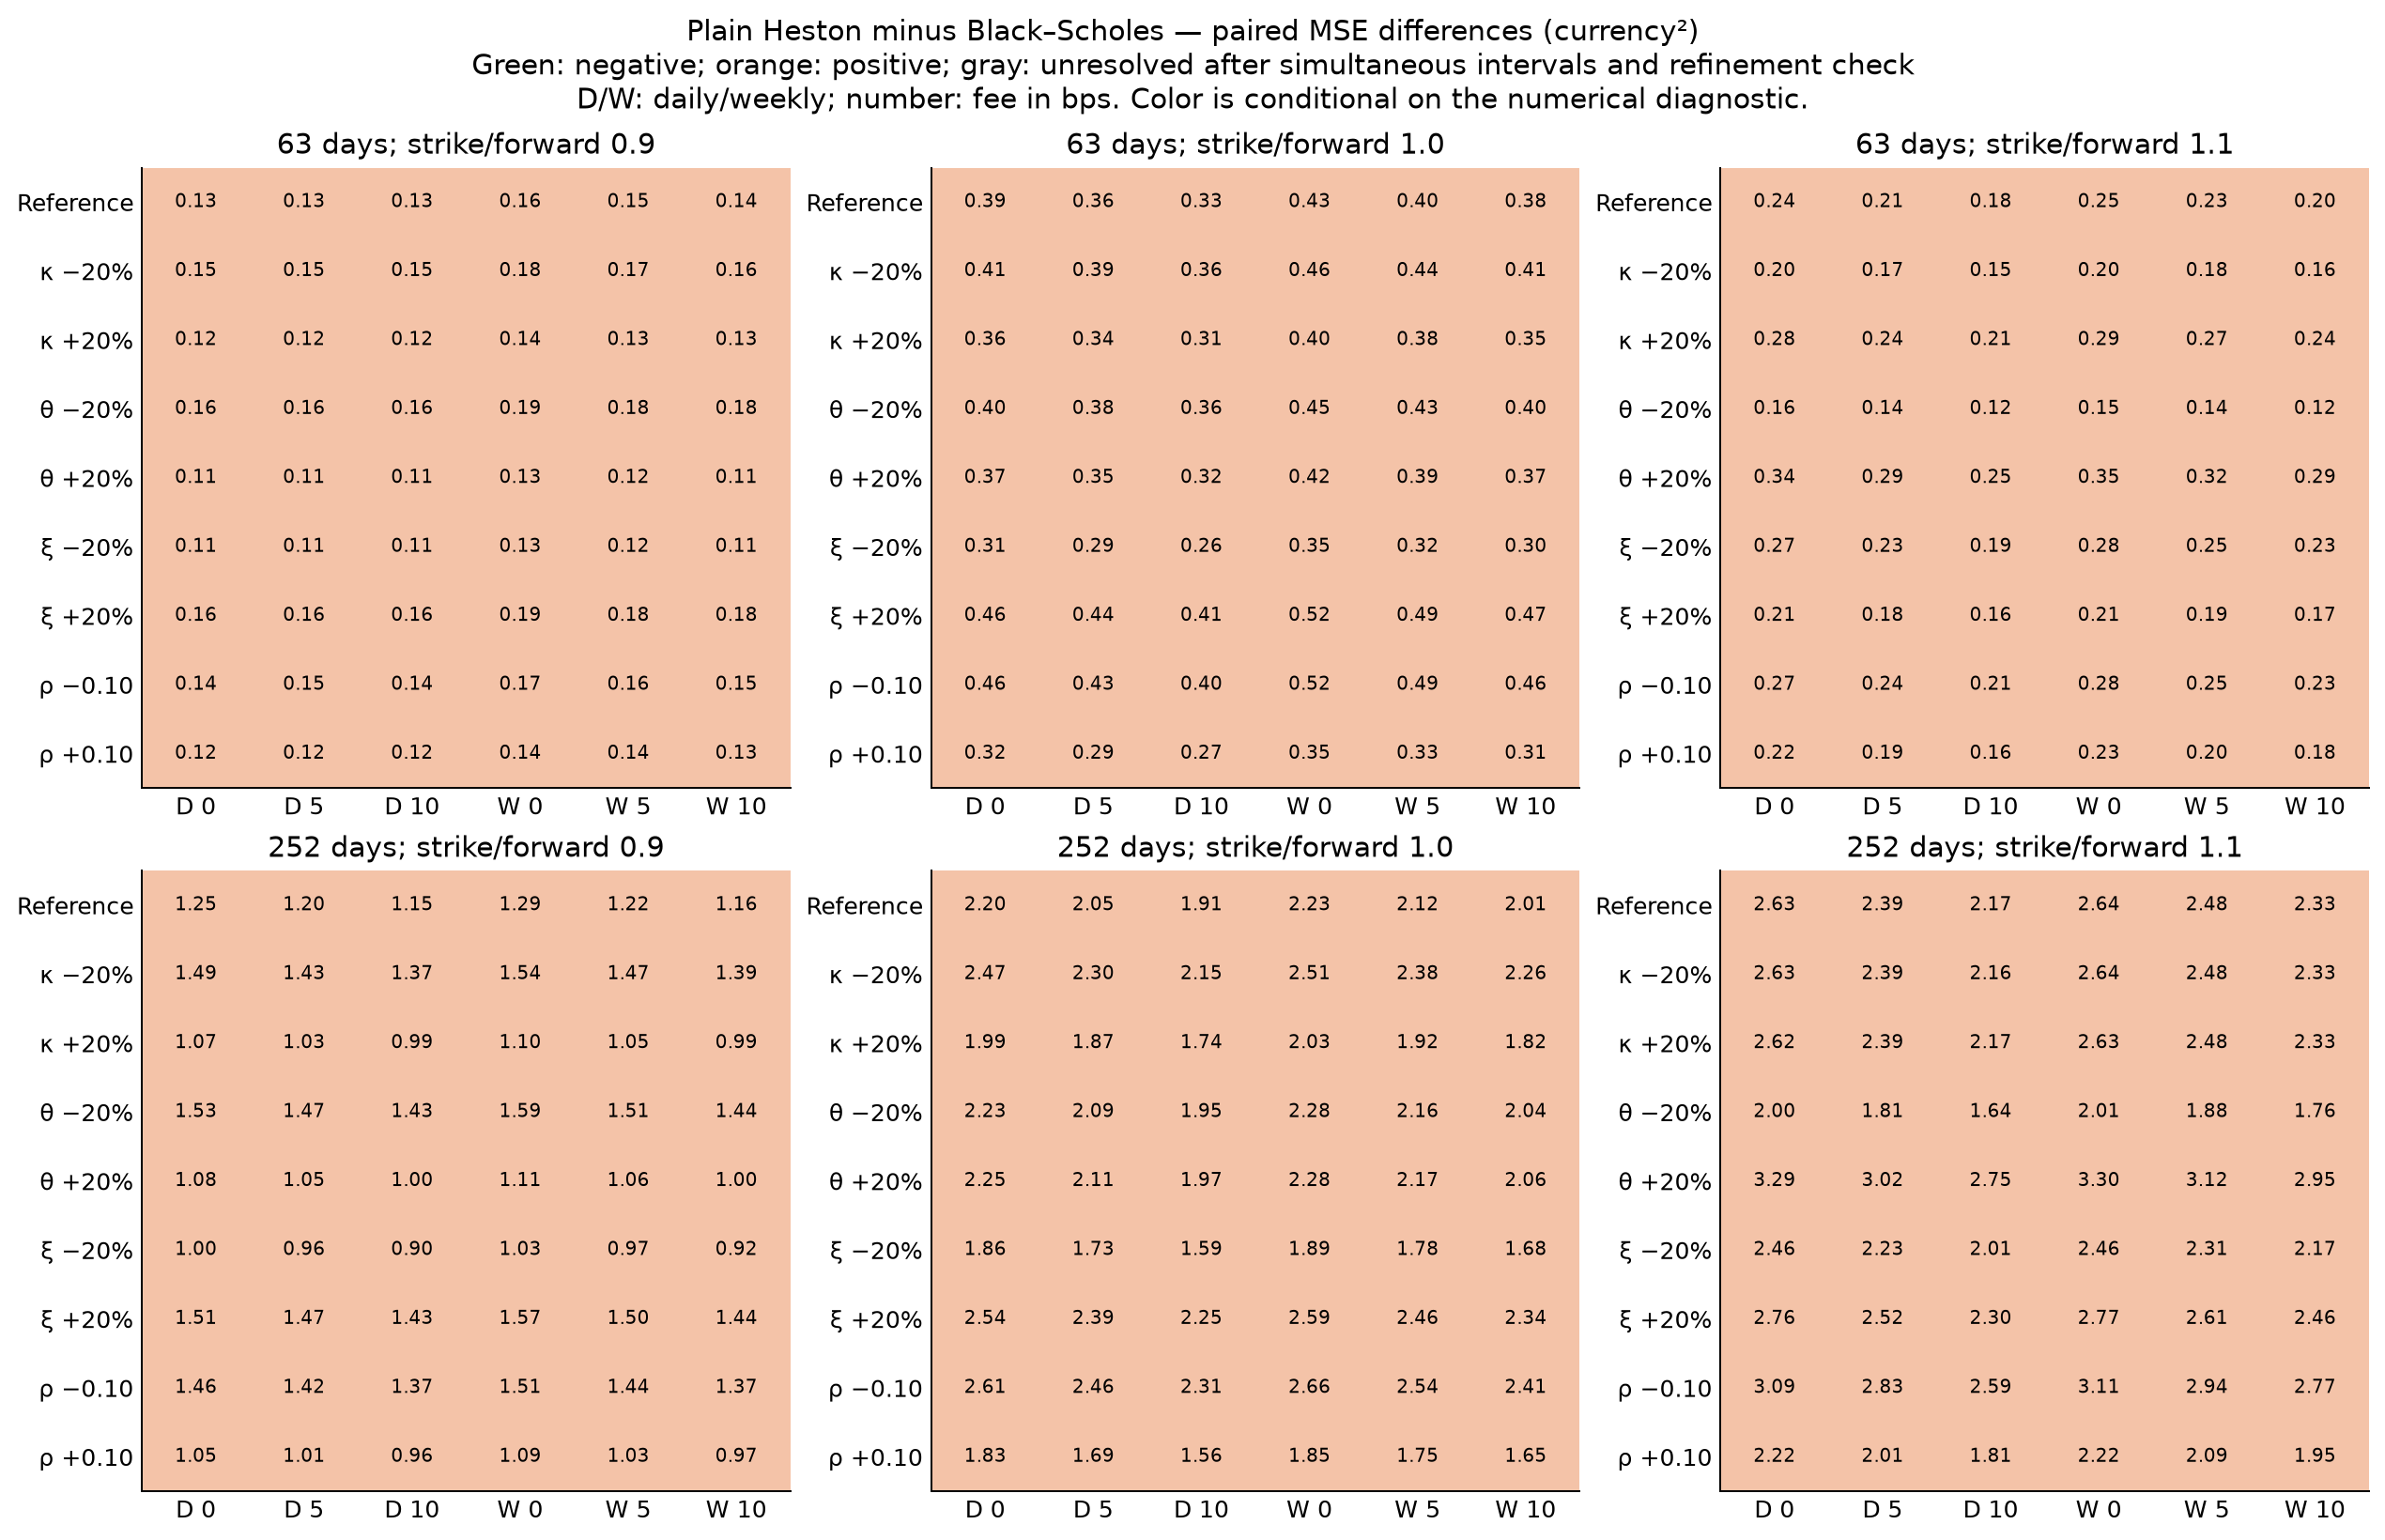

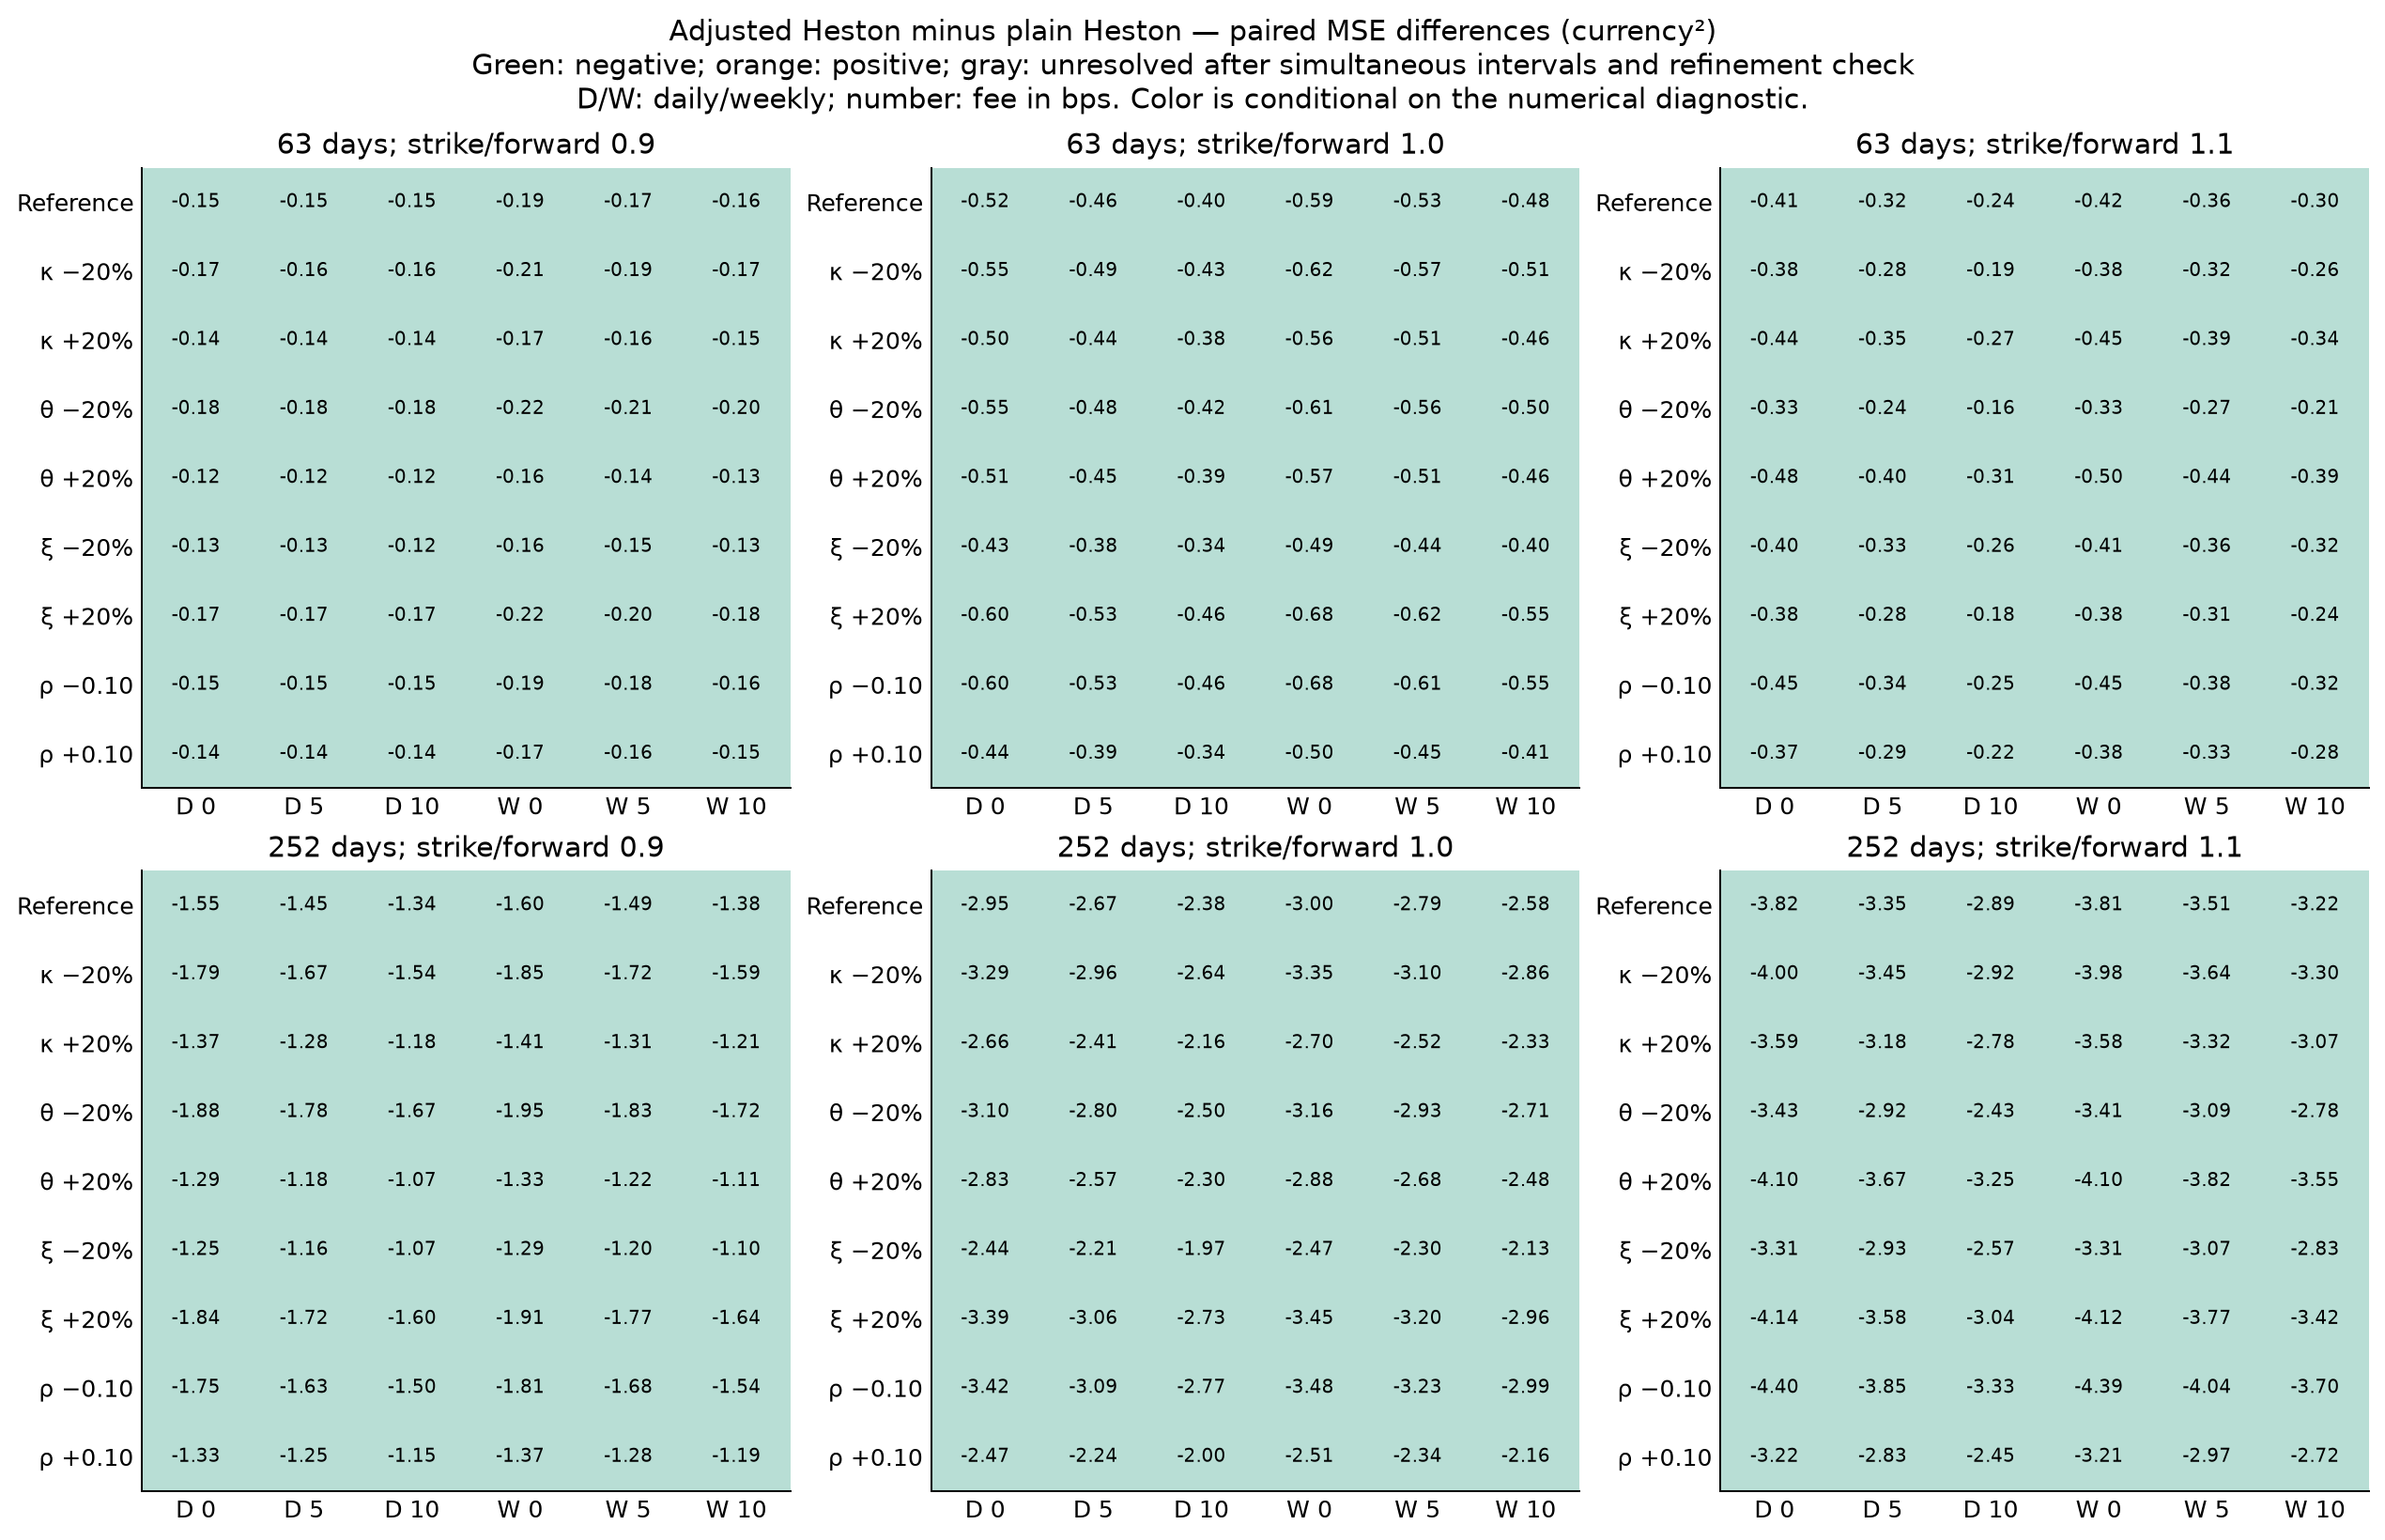

In [6]:
display(Image(filename=str(R/'Heston_minus_BS_grid.png')))
display(Image(filename=str(R/'Adjusted_minus_Heston_grid.png')))

## 6. Inspect uncertainty, convergence, and failures

Pointwise and Bonferroni intervals estimate Monte Carlo uncertainty using paired squared-loss differences. They are approximate and require finite variance of those differences. The refinement expansion is a numerical-sensitivity diagnostic, not a simultaneous confidence bound on numerical bias. The 2,048-path check is nested inside the 4,096-path run.

In [7]:
contrasts = pd.read_csv(R/'contrasts_with_convergence.csv')
display(contrasts.query("scenario == 'reference' and fee_bps == 0 and rebalance_days == 1").round(5))
display(pd.read_csv(R/'sign_counts.csv'))
print('Pricing diagnostics:', json.dumps(json.loads((R/'pricing_diagnostics.json').read_text()), indent=2))
print('Path diagnostics:', json.dumps(json.loads((R/'path_diagnostics.json').read_text()), indent=2))

Pricing diagnostics: {
  "heston_points": 34836486,
  "quadrature_disagreements": 658128,
  "roundoff_price_bound_adjustments": 260727,
  "iv_points": 3870720,
  "iv_zero_time_value_limits": 64174,
  "quadrature_refinement_points": 658128,
  "quadrature_refinement_acceptances": 435629,
  "quantlib_fallback_points": 222499,
  "quantlib_zero_variance_regularizations": 142,
  "quantlib_integrator_recoveries": 4617
}
Path diagnostics: {
  "scheme": "full-truncation latent variance Euler; log-stock Euler",
  "rng": "NumPy default_rng / PCG64",
  "seed": 20260925,
  "n_paths": 4096,
  "days": 252,
  "trading_days": 252,
  "substeps_per_day": 8,
  "coupling_substeps_per_day": 8,
  "integration_dt_years": 0.000496031746031746,
  "latent_negative_step_count": 561,
  "latent_negative_step_fraction": 6.793794177827381e-05,
  "paths_with_latent_negative_state": 286,
  "daily_zero_variance_count_excluding_initial": 64,
  "minimum_latent_variance": -0.0004430028782277882,
  "invalid_path_count": 0,


,maturity_days,strike_over_forward,scenario,fee_bps,rebalance_days,contrast,difference,se,ci95_low,ci95_high,sim95_low,sim95_high,n_paths,first_half_difference,refinement_shift,refinement_se,refinement_margin,expanded_low,expanded_high,supported_sign
0,63,0.9,reference,0,1,Heston_minus_BS,0.13167,0.00781,0.11635,0.14699,0.10075,0.16259,4096,0.14654,-0.00067,0.00062,0.00189,0.09886,0.16449,positive
1,63,0.9,reference,0,1,Adjusted_minus_Heston,-0.15282,0.01253,-0.17738,-0.12825,-0.20240,-0.10323,4096,-0.17675,0.00109,0.00107,0.00319,-0.20559,-0.10004,negative
108,63,1.0,reference,0,1,Heston_minus_BS,0.38543,0.01125,0.36337,0.40749,0.34090,0.42995,4096,0.40422,0.00159,0.00099,0.00352,0.33738,0.43347,positive
109,63,1.0,reference,0,1,Adjusted_minus_Heston,-0.52389,0.02049,-0.56405,-0.48373,-0.60496,-0.44282,4096,-0.55995,-0.00350,0.00178,0.00699,-0.61195,-0.43583,negative
216,63,1.1,reference,0,1,Heston_minus_BS,0.24496,0.00906,0.22720,0.26272,0.20911,0.28081,4096,0.24330,0.00149,0.00085,0.00316,0.20595,0.28397,positive
217,63,1.1,reference,0,1,Adjusted_minus_Heston,-0.41346,0.01855,-0.44984,-0.37709,-0.48689,-0.34004,4096,-0.41473,-0.00300,0.00187,0.00666,-0.49354,-0.33338,negative
324,252,0.9,reference,0,1,Heston_minus_BS,1.24618,0.03770,1.17227,1.32010,1.09700,1.39536,4096,1.25691,-0.00007,0.00345,0.00683,1.09018,1.40219,positive
325,252,0.9,reference,0,1,Adjusted_minus_Heston,-1.54982,0.05788,-1.66329,-1.43635,-1.77884,-1.32079,4096,-1.58571,0.00349,0.00511,0.01351,-1.79235,-1.30728,negative
432,252,1.0,reference,0,1,Heston_minus_BS,2.19708,0.05342,2.09234,2.30182,1.98568,2.40848,4096,2.15583,-0.00124,0.00442,0.00990,1.97578,2.41837,positive
433,252,1.0,reference,0,1,Adjusted_minus_Heston,-2.94976,0.08496,-3.11633,-2.78319,-3.28596,-2.61356,4096,-2.90138,0.00285,0.00742,0.01739,-3.30335,-2.59617,negative


,contrast,negative,positive
0,Adjusted_minus_Heston,324,0
1,Heston_minus_BS,0,324


## 7. Reproduce deliberately

Run from the project root. Scripts refuse to overwrite a completed study; archive the matching output directory before an intentional rerun. `requirements-lock.txt` records package versions, and each manifest records seeds plus code and protocol hashes.

```bash
.venv/bin/python simulation/validate_paths.py
.venv/bin/python simulation/validate_accounting.py
.venv/bin/python simulation/validate_pricing.py
.venv/bin/python simulation/run_study.py pilot
.venv/bin/python simulation/run_study.py main
.venv/bin/python simulation/run_study.py convergence --substeps 8
.venv/bin/python simulation/run_study.py convergence --substeps 16
.venv/bin/python simulation/run_study.py summarize-convergence
.venv/bin/python simulation/analyze_results.py
```

`RESULTS_REPORT.md` explains the findings and writing implications. All conclusions remain conditional on the tested Heston regime, observed variance, selected errors, and accounting assumptions.